# 02 — Baseline: MedGemma 4B-it Zero-Shot

**Purpose:** Establish the pre-fine-tuning performance anchor.  
Every subsequent result (fine-tuned model, shift-corrected sampler) is compared to these numbers.

**Protocol (MedGemma 1.5 Technical Report §3.1):**
- Temperature = 0.0 (greedy decoding — no sampling variance)
- No few-shot examples (pure zero-shot)
- Metrics computed under both uncertainty policies: `present` and `absent`

**Steps:**
```
STEP 1  Load test split
STEP 2  Load MedGemma 4B-it (4-bit NF4 QLoRA)
STEP 3  Zero-shot generation  ← slow, cached after first run
STEP 4  CheXbert labeling of hypotheses + references
STEP 5  F1-CheXbert  micro / macro / per-label  (both policies)
STEP 6  BERTScore F1
STEP 7  BLEU-4 / ROUGE-L
STEP 8  Metric summary table
STEP 9  Report figures
STEP 10 Save results to disk
```

**Requires:** GPU with ≥ 16 GB VRAM (T4 / L4 / A10G).

In [1]:
import json
import logging
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

matplotlib.rcParams['figure.dpi'] = 120
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

with open('../params.yaml') as f:
    params = yaml.safe_load(f)

DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'
PROCESSED_DIR = Path('../data/processed')
IMAGES_DIR    = Path('../') / params['data']['images_dir'] / 'images_normalized'
FIGURES_DIR   = Path('../reports/figures')
RESULTS_DIR   = Path('../reports')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

HYP_FILE = PROCESSED_DIR / 'zero_shot_hypotheses.txt'

print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Images : {IMAGES_DIR}  (exists={IMAGES_DIR.exists()})')
print(f'Hyp cache: {HYP_FILE}  (exists={HYP_FILE.exists()})')

Device : cuda
GPU    : NVIDIA RTX 4000 Ada Generation
VRAM   : 21.0 GB
Images : ../data/raw/images/images_normalized  (exists=True)
Hyp cache: ../data/processed/zero_shot_hypotheses.txt  (exists=True)


## STEP 1 — Load test split

Evaluate: correct size? Label columns present? `frontal` column has filenames?

In [2]:
from src.data.labels import CHEXBERT_LABELS

test_df = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
print(f'Test set: {len(test_df)} studies,  {test_df.shape[1]} columns')
print(f'Columns : {test_df.columns.tolist()}')

# Verify label columns are present
missing_labels = [c for c in CHEXBERT_LABELS if c not in test_df.columns]
if missing_labels:
    print(f'WARNING — missing label columns: {missing_labels}')
    print('Run the labels DVC stage first: dvc repro labels')
else:
    print(f'Label columns present: {len(CHEXBERT_LABELS)}/14')

# Drop rows without findings (generation target)
test_df = test_df[test_df['findings'].notna() & (test_df['findings'].str.strip() != '')].reset_index(drop=True)
print(f'\nAfter dropping empty findings: {len(test_df)} studies')

# Label prevalences in test set
test_prev = test_df[CHEXBERT_LABELS].mean().sort_values(ascending=False)
print('\nTest-set label prevalences:')
print(test_prev.to_string())

Test set: 600 studies,  26 columns
Columns : ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression', 'frontal', 'lateral', 'frontal_paths', 'lateral_paths', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'No Finding']
Label columns present: 14/14

After dropping empty findings: 600 studies

Test-set label prevalences:
No Finding                    0.386667
Lung Opacity                  0.135000
Cardiomegaly                  0.123333
Enlarged Cardiomediastinum    0.075000
Atelectasis                   0.066667
Support Devices               0.046667
Lung Lesion                   0.040000
Fracture                      0.036667
Pleural Effusion              0.031667
Pleural Other                 0.015000
Edema                         0.013333
Pneumonia                     0.010000
Consolida

## STEP 2 — Load MedGemma 4B-it

4-bit NF4 quantization via bitsandbytes. Fits comfortably in 16 GB VRAM.  
First run downloads ~8 GB from HuggingFace — ensure `HF_TOKEN` is set.

In [3]:
from transformers import AutoProcessor, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = params['model']['base_model_id']  # google/medgemma-4b-it

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print(f'Loading processor from {MODEL_ID} ...')
processor = AutoProcessor.from_pretrained(MODEL_ID)

print(f'Loading model (4-bit NF4) ...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_cfg if DEVICE == 'cuda' else None,
    device_map='auto' if DEVICE == 'cuda' else None,
    torch_dtype=torch.bfloat16,
    attn_implementation='eager',
)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'\nModel loaded. Total parameters: {n_params / 1e9:.2f} B')
if torch.cuda.is_available():
    used = torch.cuda.memory_allocated() / 1e9
    print(f'GPU memory after load: {used:.2f} GB')

/home/jvazquez/diego_villalba/ReportCXR/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading processor from google/medgemma-4b-it ...


INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/processor_config.json "HTTP/1.1 200 OK"
INFO HTTP Request: GET https://huggingface.co/api/models/google/medgemma-4b-it/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/processor_config.json "HTTP/1.1 200 OK"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/chat_template.jinja "HTTP/1.1 200 OK"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 Not Found"
INFO HTTP Request: GET https://huggingface.co/api/models/google/medgemma-4b-it/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://huggi

Loading model (4-bit NF4) ...


INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 883/883 [00:01<00:00, 612.24it/s] 
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/generation_config.json "HTTP/1.1 200 OK"



Model loaded. Total parameters: 2.49 B
GPU memory after load: 3.23 GB


## STEP 3 — Zero-shot generation

- Each test study → frontal CXR image + indication → generated Findings text
- Temperature = 0 (greedy, `do_sample=False`)
- Hypotheses saved to `data/processed/zero_shot_hypotheses.txt` — **skip inference on re-run**

Evaluate: do the generated reports look clinically plausible?

In [4]:
from PIL import Image

SYSTEM_PROMPT = (
    'You are an expert radiologist. '
    'Write only the Findings section of a radiology report for the chest X-ray shown. '
    'Be concise and clinical. Do not include an Impression section.'
)


def _build_messages(indication: str | None, has_image: bool) -> list:
    content = []
    if has_image:
        content.append({'type': 'image'})
    user_text = SYSTEM_PROMPT
    if indication and indication.strip() and indication.strip().lower() not in {'nan', 'none'}:
        user_text = f'Indication: {indication.strip()}\n{SYSTEM_PROMPT}'
    content.append({'type': 'text', 'text': user_text})
    return [{'role': 'user', 'content': content}]


@torch.inference_mode()
def generate_report(row: pd.Series) -> str:
    """Generate a zero-shot findings report for one test study."""
    # Load frontal image
    pil_image = None
    frontal_files = row.get('frontal', [])
    if isinstance(frontal_files, list) and frontal_files:
        img_path = IMAGES_DIR / frontal_files[0]
        if img_path.exists():
            try:
                pil_image = Image.open(img_path).convert('RGB')
            except Exception:
                pil_image = None

    indication = str(row.get('indication', '')) if pd.notna(row.get('indication')) else ''
    messages   = _build_messages(indication, has_image=pil_image is not None)

    # Tokenize via chat template
    text = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    proc_kwargs = dict(text=text, return_tensors='pt', padding=True)
    if pil_image is not None:
        proc_kwargs['images'] = [pil_image]
    inputs = processor(**proc_kwargs)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    input_len = inputs['input_ids'].shape[1]
    outputs   = model.generate(
        **inputs,
        max_new_tokens=params['model']['max_new_tokens'],
        do_sample=False,           # greedy = temperature 0
        pad_token_id=processor.tokenizer.eos_token_id,
    )
    new_tokens = outputs[0][input_len:]
    return processor.tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


print('generate_report() defined. Ready to run inference.')

generate_report() defined. Ready to run inference.


In [5]:
from tqdm.auto import tqdm

if HYP_FILE.exists():
    print(f'Loading cached hypotheses from {HYP_FILE}')
    hypotheses = HYP_FILE.read_text().splitlines()
    assert len(hypotheses) == len(test_df), (
        f'Cache mismatch: {len(hypotheses)} lines vs {len(test_df)} test studies. '
        f'Delete {HYP_FILE} and re-run to regenerate.'
    )
    print(f'Loaded {len(hypotheses)} hypotheses.')
else:
    print(f'Running zero-shot inference on {len(test_df)} studies ...')
    hypotheses = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='generating'):
        hyp = generate_report(row)
        # Newlines break the line-per-study format — collapse to space
        hypotheses.append(hyp.replace('\n', ' '))

    HYP_FILE.parent.mkdir(parents=True, exist_ok=True)
    HYP_FILE.write_text('\n'.join(hypotheses))
    print(f'Saved {len(hypotheses)} hypotheses to {HYP_FILE}')

references = test_df['findings'].str.strip().str.replace('\n', ' ', regex=False).tolist()
print(f'\nHypotheses: {len(hypotheses)}  |  References: {len(references)}')

Loading cached hypotheses from ../data/processed/zero_shot_hypotheses.txt
Loaded 600 hypotheses.

Hypotheses: 600  |  References: 600


In [6]:
# Qualitative sanity check — 3 examples
print('=== QUALITATIVE EXAMPLES (zero-shot) ===\n')
for i in [0, 1, 2]:
    row = test_df.iloc[i]
    print(f'UID {row["uid"]} | indication: {str(row.get("indication", ""))[:80]}')
    print(f'  REFERENCE : {references[i][:250]}')
    print(f'  GENERATED : {hypotheses[i][:250]}')
    print()

=== QUALITATIVE EXAMPLES (zero-shot) ===

UID 4 | indication: XXXX-year-old XXXX with XXXX.
  REFERENCE : There are diffuse bilateral interstitial and alveolar opacities consistent with chronic obstructive lung disease and bullous emphysema. There are irregular opacities in the left lung apex, that could represent a cavitary lesion in the left lung apex.
  GENERATED : Findings:  The lungs are clear bilaterally without evidence of consolidation, effusion, or pneumothorax. The heart size is normal. The mediastinum is unremarkable. The bony structures are intact.

UID 5 | indication: Chest and nasal congestion.
  REFERENCE : The cardiomediastinal silhouette and pulmonary vasculature are within normal limits. There is no pneumothorax or pleural effusion. There are no focal areas of consolidation. Cholecystectomy clips are present. Small T-spine osteophytes. There is biapi
  GENERATED : Findings:  The lungs are clear bilaterally. The heart size is normal. The mediastinum is unremarkable. Th

## STEP 4 — CheXbert labeling

Run CheXbert over both hypotheses and references under both uncertainty policies.  
Cached to parquet after first run (each pass takes ~5–10 min on CPU, <1 min on GPU).

Evaluate: do hypothesis label distributions look reasonable compared to references?

In [7]:
from src.data.labels import run_chexbert

CHEXBERT_DEVICE = DEVICE  # use GPU if available — much faster

# Policy = 'present'  (uncertain → 1; default handout policy)
HYP_PRESENT_CACHE = PROCESSED_DIR / 'baseline_hyp_labels_present.parquet'
REF_PRESENT_CACHE = PROCESSED_DIR / 'baseline_ref_labels_present.parquet'

def _load_or_compute_labels(texts, policy, cache_path, label_name):
    if cache_path.exists():
        print(f'  Loading {label_name} (policy={policy}) from cache ...')
        return pd.read_parquet(cache_path).to_numpy(dtype=np.int8)
    print(f'  Computing {label_name} labels (policy={policy}) ...')
    mat = run_chexbert(texts, uncertain_policy=policy, device=CHEXBERT_DEVICE)
    df_cache = pd.DataFrame(mat, columns=CHEXBERT_LABELS)
    df_cache.to_parquet(cache_path, index=False)
    print(f'  Cached to {cache_path}')
    return mat


print('Policy = present (uncertain → 1):')
hyp_mat_present = _load_or_compute_labels(hypotheses, 'present', HYP_PRESENT_CACHE, 'hyp')
ref_mat_present = _load_or_compute_labels(references, 'present', REF_PRESENT_CACHE, 'ref')

print('\nLabel prevalence comparison (policy=present):')
prev_ref  = pd.Series(ref_mat_present.mean(axis=0), index=CHEXBERT_LABELS, name='reference')
prev_hyp  = pd.Series(hyp_mat_present.mean(axis=0), index=CHEXBERT_LABELS, name='hypothesis')
prev_comp = pd.concat([prev_ref, prev_hyp], axis=1)
prev_comp['diff'] = prev_hyp - prev_ref
display(prev_comp.sort_values('reference', ascending=False).round(3))

Policy = present (uncertain → 1):
  Loading hyp (policy=present) from cache ...
  Loading ref (policy=present) from cache ...

Label prevalence comparison (policy=present):


,reference,hypothesis,diff
No Finding,0.387,0.928,0.542
Lung Opacity,0.135,0.017,-0.118
Cardiomegaly,0.123,0.003,-0.120
Enlarged Cardiomediastinum,0.075,0.000,-0.075
Atelectasis,0.067,0.005,-0.062
Support Devices,0.047,0.010,-0.037
Lung Lesion,0.040,0.013,-0.027
Fracture,0.037,0.003,-0.033
Pleural Effusion,0.032,0.005,-0.027
Pleural Other,0.015,0.002,-0.013


In [8]:
# Policy = 'absent'  (uncertain → 0; ablation)
HYP_ABSENT_CACHE = PROCESSED_DIR / 'baseline_hyp_labels_absent.parquet'
REF_ABSENT_CACHE = PROCESSED_DIR / 'baseline_ref_labels_absent.parquet'

print('Policy = absent (uncertain → 0):')
hyp_mat_absent = _load_or_compute_labels(hypotheses, 'absent', HYP_ABSENT_CACHE, 'hyp')
ref_mat_absent = _load_or_compute_labels(references, 'absent', REF_ABSENT_CACHE, 'ref')
print('Done.')

Policy = absent (uncertain → 0):
  Loading hyp (policy=absent) from cache ...
  Loading ref (policy=absent) from cache ...
Done.


## STEP 5 — F1-CheXbert

Compute micro-average F1, macro-average F1, and per-label F1 using sklearn's
`classification_report` on the CheXbert label matrices.  
Both policies are computed; `present` is the primary metric.

Evaluate: which labels does zero-shot MedGemma fail on?

In [9]:
from sklearn.metrics import classification_report


def _compute_f1_chexbert(ref_mat, hyp_mat, policy_name: str) -> dict:
    cr = classification_report(
        ref_mat, hyp_mat,
        target_names=CHEXBERT_LABELS,
        output_dict=True,
        zero_division=0,
    )
    per_label = {label: cr[label]['f1-score'] for label in CHEXBERT_LABELS}
    return {
        f'f1_chexbert_micro_{policy_name}': cr['micro avg']['f1-score'],
        f'f1_chexbert_macro_{policy_name}': cr['macro avg']['f1-score'],
        f'per_label_f1_{policy_name}': per_label,
        f'_cr_{policy_name}': cr,
    }


f1_present = _compute_f1_chexbert(ref_mat_present, hyp_mat_present, 'present')
f1_absent  = _compute_f1_chexbert(ref_mat_absent,  hyp_mat_absent,  'absent')

print('F1-CheXbert (policy = present):')
print(f"  Micro F1 : {f1_present['f1_chexbert_micro_present']:.4f}")
print(f"  Macro F1 : {f1_present['f1_chexbert_macro_present']:.4f}")
print('\nF1-CheXbert (policy = absent):')
print(f"  Micro F1 : {f1_absent['f1_chexbert_micro_absent']:.4f}")
print(f"  Macro F1 : {f1_absent['f1_chexbert_macro_absent']:.4f}")

print('\nPer-label F1 (policy = present):')
per_label_df = pd.Series(f1_present['per_label_f1_present'], name='F1 (present)')
per_label_df = per_label_df.sort_values(ascending=False)
display(per_label_df.to_frame().round(3))

F1-CheXbert (policy = present):
  Micro F1 : 0.3967
  Macro F1 : 0.1416

F1-CheXbert (policy = absent):
  Micro F1 : 0.4222
  Macro F1 : 0.1403

Per-label F1 (policy = present):


,F1 (present)
No Finding,0.560
Pneumothorax,0.500
Support Devices,0.353
Pneumonia,0.222
Lung Opacity,0.110
Pleural Effusion,0.091
Fracture,0.083
Lung Lesion,0.062
Enlarged Cardiomediastinum,0.000
Cardiomegaly,0.000


## STEP 6 — BERTScore

Contextual similarity using DeBERTa-XL-MNLI as the reference model.  
Returns per-study F1 scores (useful for distribution plots).

Evaluate: mean BERTScore F1 — is the model generating plausible clinical language?

In [10]:
import bert_score.utils as _bsu
from bert_score import score as bert_score_fn

# deberta-xlarge-mnli stores model_max_length ≈ 1e30 in its config.
# bert_score.utils.sent_encode passes that directly to tokenizer.encode(max_length=...),
# which overflows the Rust tokenizer backend even with use_fast_tokenizer=False
# (deberta-v2 has no slow tokenizer). Patch it to cap at 512.
_orig_sent_encode = _bsu.sent_encode

def _patched_sent_encode(tokenizer, sent):
    return tokenizer.encode(sent, add_special_tokens=True, max_length=512, truncation=True)

_bsu.sent_encode = _patched_sent_encode

BERTSCORE_MODEL = params['eval']['bertscore_model']  # microsoft/deberta-xlarge-mnli

print(f'Computing BERTScore with {BERTSCORE_MODEL} ...')
bp, br, bf = bert_score_fn(
    hypotheses,
    references,
    model_type=BERTSCORE_MODEL,
    device=DEVICE,
    verbose=True,
)

_bsu.sent_encode = _orig_sent_encode  # restore after use

bertscore_f1        = float(bf.mean())
bertscore_per_study = bf.numpy()  # shape (n,)

print(f'\nBERTScore — precision: {float(bp.mean()):.4f} | recall: {float(br.mean()):.4f} | F1: {bertscore_f1:.4f}')

INFO HTTP Request: HEAD https://huggingface.co/microsoft/deberta-xlarge-mnli/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-xlarge-mnli/5b07a9086c1dbb79981ff7b05b4d1ad83b3af51c/config.json "HTTP/1.1 200 OK"


Computing BERTScore with microsoft/deberta-xlarge-mnli ...


INFO HTTP Request: HEAD https://huggingface.co/microsoft/deberta-xlarge-mnli/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-xlarge-mnli/5b07a9086c1dbb79981ff7b05b4d1ad83b3af51c/tokenizer_config.json "HTTP/1.1 200 OK"
INFO HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-xlarge-mnli/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-xlarge-mnli/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO HTTP Request: HEAD https://huggingface.co/microsoft/deberta-xlarge-mnli/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-xlarge-mnli/5b07a9086c1dbb79981ff7b05b4d1ad83b3af51c/config.json "HTTP/1.1 200 OK"
INFO HTTP Request: HEAD https://huggingfac

calculating scores...
computing bert embedding.


100%|██████████| 11/11 [00:08<00:00,  1.28it/s]


computing greedy matching.


100%|██████████| 10/10 [00:00<00:00, 109.40it/s]

done in 8.72 seconds, 68.82 sentences/sec

BERTScore — precision: 0.6961 | recall: 0.6948 | F1: 0.6938


## STEP 7 — BLEU-4 / ROUGE-L

NLG metrics reported for cross-paper comparability only.  
**Note:** BLEU / ROUGE measure n-gram overlap, not clinical correctness; they are
secondary to F1-CheXbert and BERTScore in this project's hierarchy.

In [11]:
import evaluate

bleu_metric  = evaluate.load('bleu')
rouge_metric = evaluate.load('rouge')

# BLEU expects list-of-str predictions and list-of-list-of-str references
bleu_result = bleu_metric.compute(
    predictions=hypotheses,
    references=[[r] for r in references],
    max_order=params['eval']['bleu_max_order'],
)
bleu4 = bleu_result['bleu']

rouge_result = rouge_metric.compute(
    predictions=hypotheses,
    references=references,
    use_aggregator=True,
)
rouge_l = rouge_result['rougeL']

# Per-study BLEU-4 for distribution plot
bleu_per_study = []
for h, r in zip(hypotheses, references):
    try:
        b = bleu_metric.compute(predictions=[h], references=[[r]], max_order=4)['bleu']
    except Exception:
        b = 0.0
    bleu_per_study.append(b)
bleu_per_study = np.array(bleu_per_study)

print(f'BLEU-4  : {bleu4:.4f}')
print(f'ROUGE-L : {rouge_l:.4f}')

INFO Using default tokenizer.


BLEU-4  : 0.0957
ROUGE-L : 0.2631


## STEP 8 — Metric summary table

Primary metrics in bold — NLG metrics are secondary.

In [12]:
summary = {
    'F1-CheXbert micro (present)': f1_present['f1_chexbert_micro_present'],
    'F1-CheXbert macro (present)': f1_present['f1_chexbert_macro_present'],
    'F1-CheXbert micro (absent)' : f1_absent['f1_chexbert_micro_absent'],
    'F1-CheXbert macro (absent)' : f1_absent['f1_chexbert_macro_absent'],
    'BERTScore F1'               : bertscore_f1,
    'BLEU-4'                     : bleu4,
    'ROUGE-L'                    : rouge_l,
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Zero-Shot Baseline'])
summary_df.index.name = 'Metric'
display(summary_df.round(4))

,Zero-Shot Baseline
Metric,
F1-CheXbert micro (present),0.3967
F1-CheXbert macro (present),0.1416
F1-CheXbert micro (absent),0.4222
F1-CheXbert macro (absent),0.1403
BERTScore F1,0.6938
BLEU-4,0.0957
ROUGE-L,0.2631


## STEP 9 — Report figures

Four figures saved to `reports/figures/`:

| File | Caption |
|------|---------|
| `baseline_per_label_f1.png` | Per-label F1-CheXbert (zero-shot baseline, policy=present) |
| `baseline_policy_ablation.png` | Micro/macro F1 under present vs absent uncertainty policy |
| `baseline_score_distributions.png` | Per-study BERTScore F1 and BLEU-4 distributions |
| `baseline_qualitative_examples.png` | Three generated vs. reference report pairs |

Saved ../reports/figures/baseline_per_label_f1.png


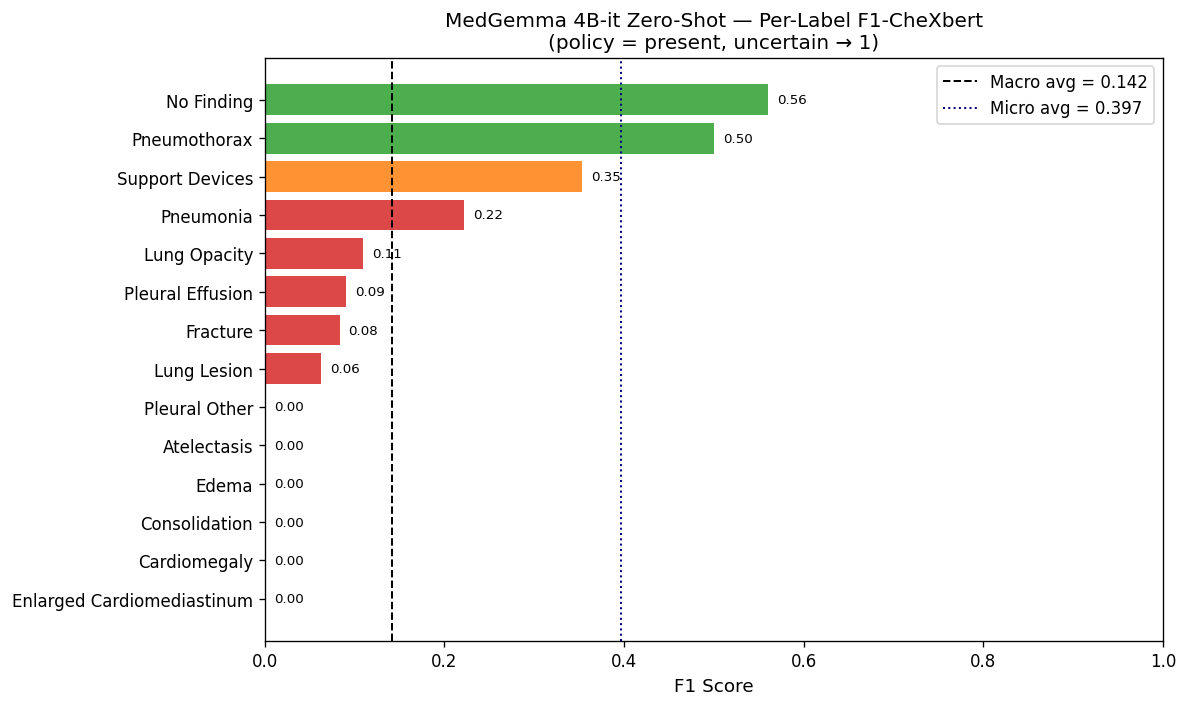

In [13]:
# ── Figure 1: Per-label F1 (policy = present) ─────────────────────────────────
per_label_present = pd.Series(f1_present['per_label_f1_present']).sort_values(ascending=True)
per_label_absent  = pd.Series(f1_absent['per_label_f1_absent'])

fig, ax = plt.subplots(figsize=(10, 6))

y_pos  = np.arange(len(per_label_present))
colors = ['#d62728' if v < 0.3 else '#ff7f0e' if v < 0.5 else '#2ca02c'
          for v in per_label_present.values]

bars = ax.barh(y_pos, per_label_present.values, color=colors, alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(per_label_present.index, fontsize=10)
ax.set_xlabel('F1 Score', fontsize=11)
ax.set_title('MedGemma 4B-it Zero-Shot — Per-Label F1-CheXbert\n(policy = present, uncertain → 1)', fontsize=12)
ax.set_xlim(0, 1.0)
ax.axvline(f1_present['f1_chexbert_macro_present'], color='black', linestyle='--',
           linewidth=1.2, label=f"Macro avg = {f1_present['f1_chexbert_macro_present']:.3f}")
ax.axvline(f1_present['f1_chexbert_micro_present'], color='navy', linestyle=':',
           linewidth=1.2, label=f"Micro avg = {f1_present['f1_chexbert_micro_present']:.3f}")

# Value labels on bars
for bar, val in zip(bars, per_label_present.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=8)

ax.legend(fontsize=10)
plt.tight_layout()

fig_path = FIGURES_DIR / 'baseline_per_label_f1.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved {fig_path}')
plt.show()

Saved ../reports/figures/baseline_policy_ablation.png


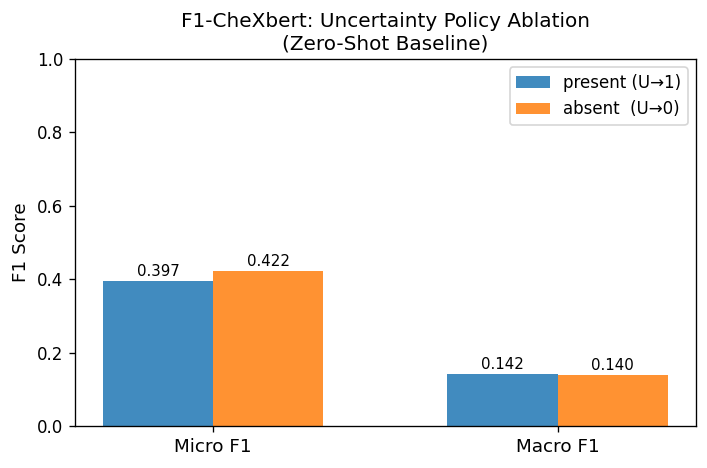

In [14]:
# ── Figure 2: Policy ablation (present vs absent) ─────────────────────────────
labels_abl = ['Micro F1', 'Macro F1']
vals_present = [
    f1_present['f1_chexbert_micro_present'],
    f1_present['f1_chexbert_macro_present'],
]
vals_absent = [
    f1_absent['f1_chexbert_micro_absent'],
    f1_absent['f1_chexbert_macro_absent'],
]

x   = np.arange(len(labels_abl))
w   = 0.32
fig, ax = plt.subplots(figsize=(6, 4))

b1 = ax.bar(x - w/2, vals_present, w, label='present (U→1)', color='#1f77b4', alpha=0.85)
b2 = ax.bar(x + w/2, vals_absent,  w, label='absent  (U→0)', color='#ff7f0e', alpha=0.85)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels_abl, fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_title('F1-CheXbert: Uncertainty Policy Ablation\n(Zero-Shot Baseline)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()

fig_path = FIGURES_DIR / 'baseline_policy_ablation.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved {fig_path}')
plt.show()

Saved ../reports/figures/baseline_score_distributions.png


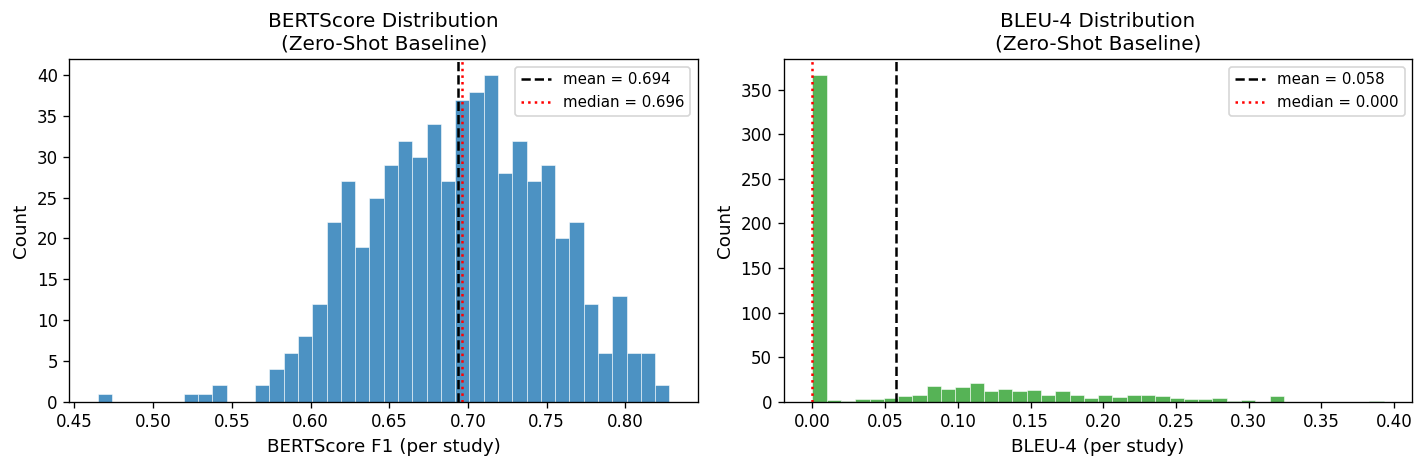

In [15]:
# ── Figure 3: Per-study score distributions ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# BERTScore F1 distribution
ax = axes[0]
ax.hist(bertscore_per_study, bins=40, color='#1f77b4', alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(bertscore_f1, color='black', linestyle='--', linewidth=1.5,
           label=f'mean = {bertscore_f1:.3f}')
ax.axvline(np.median(bertscore_per_study), color='red', linestyle=':', linewidth=1.5,
           label=f'median = {np.median(bertscore_per_study):.3f}')
ax.set_xlabel('BERTScore F1 (per study)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('BERTScore Distribution\n(Zero-Shot Baseline)', fontsize=12)
ax.legend(fontsize=9)

# BLEU-4 per-study distribution
ax = axes[1]
ax.hist(bleu_per_study, bins=40, color='#2ca02c', alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(bleu_per_study.mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'mean = {bleu_per_study.mean():.3f}')
ax.axvline(np.median(bleu_per_study), color='red', linestyle=':', linewidth=1.5,
           label=f'median = {np.median(bleu_per_study):.3f}')
ax.set_xlabel('BLEU-4 (per study)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('BLEU-4 Distribution\n(Zero-Shot Baseline)', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path = FIGURES_DIR / 'baseline_score_distributions.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved {fig_path}')
plt.show()

Saved ../reports/figures/baseline_qualitative_examples.png


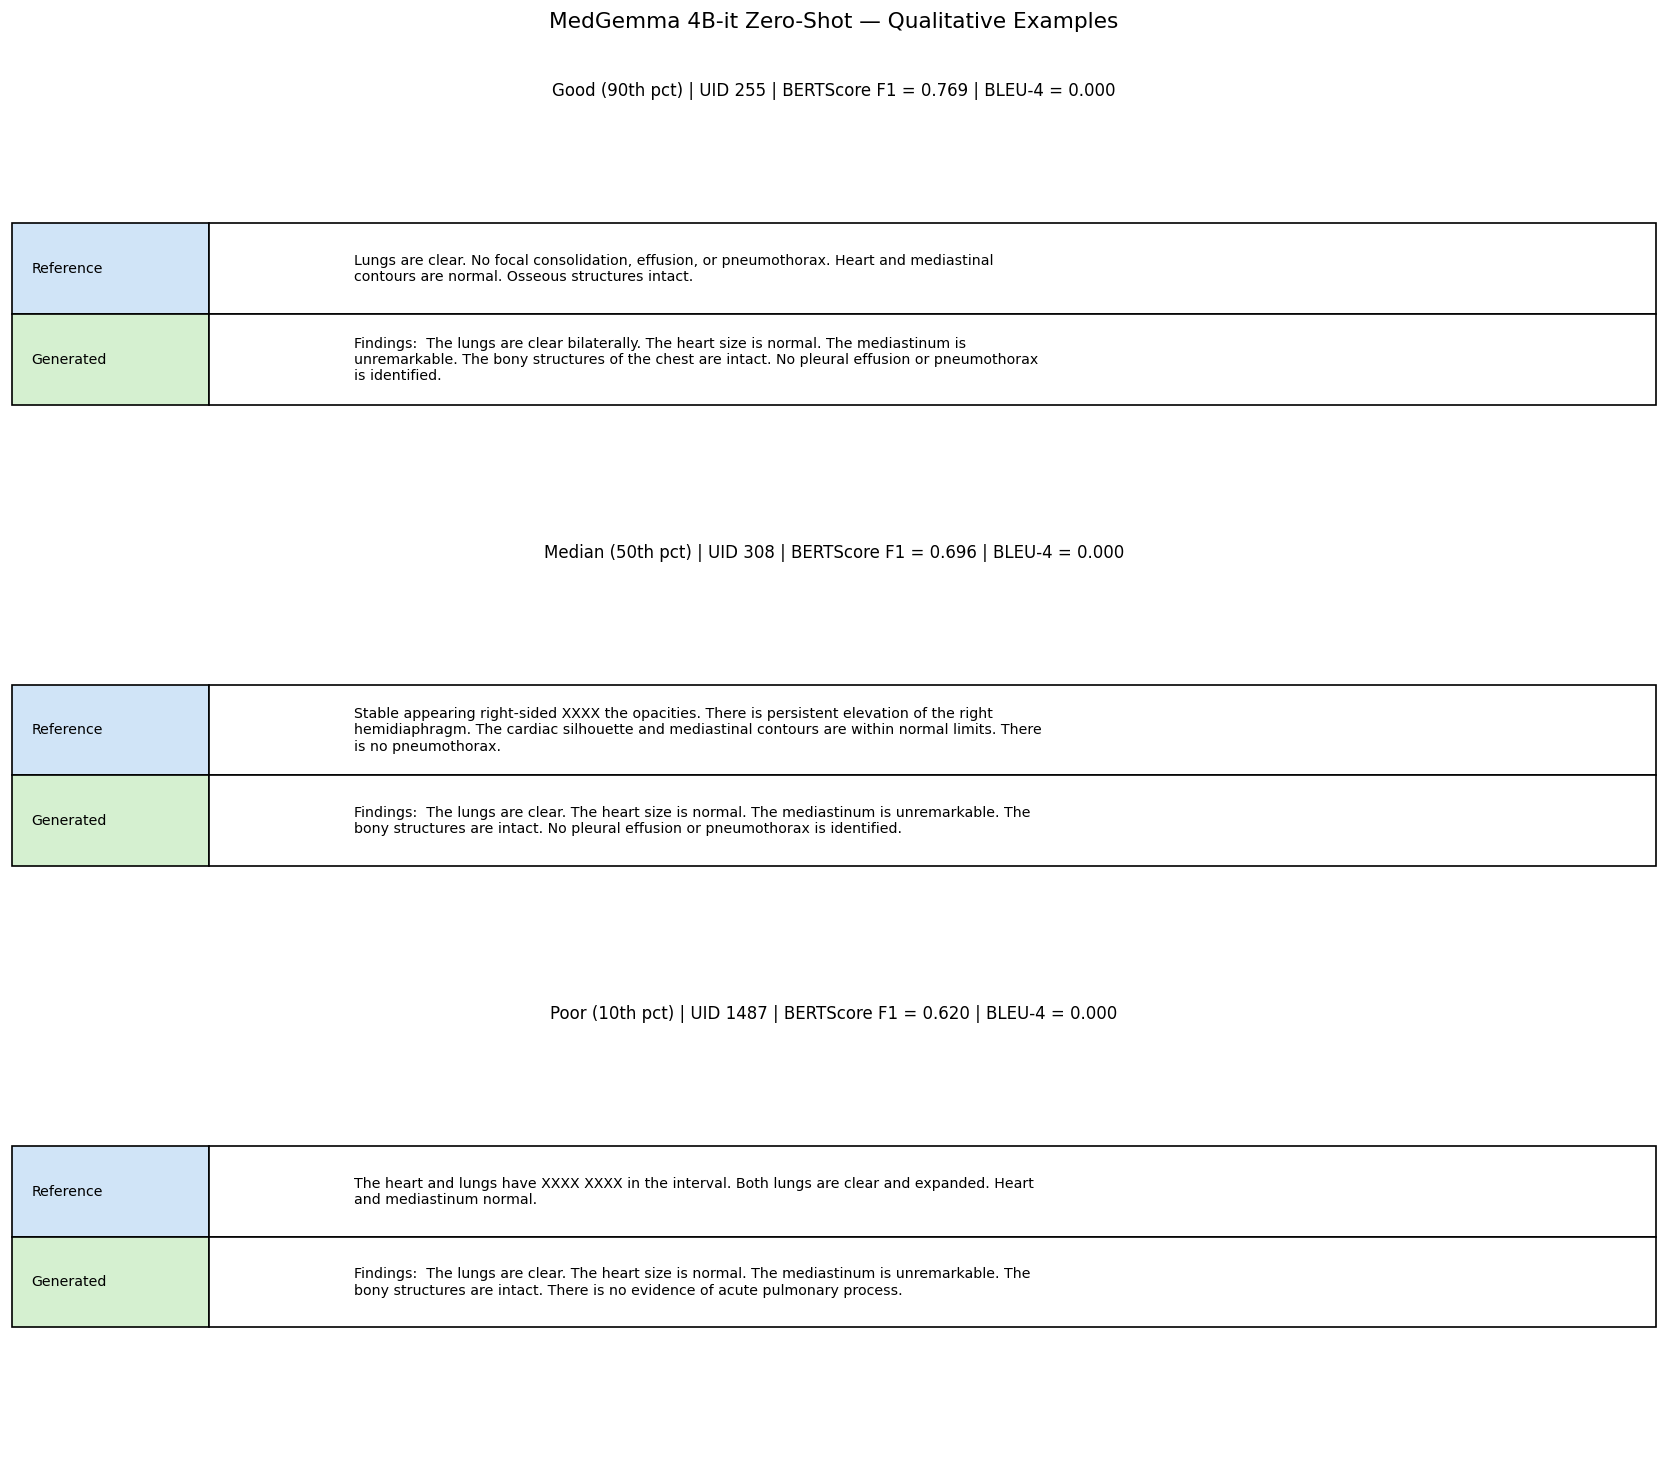

In [16]:
# ── Figure 4: Qualitative examples (rendered as matplotlib table) ──────────────
# Pick one good example, one average, one bad (by BERTScore F1)
sorted_idx  = np.argsort(bertscore_per_study)
n           = len(sorted_idx)
example_idx = [
    sorted_idx[int(n * 0.90)],   # good (90th percentile)
    sorted_idx[int(n * 0.50)],   # median
    sorted_idx[int(n * 0.10)],   # poor (10th percentile)
]

def _wrap(text: str, width: int = 80) -> str:
    import textwrap
    return '\n'.join(textwrap.wrap(text, width=width))

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
tier_labels = ['Good (90th pct)', 'Median (50th pct)', 'Poor (10th pct)']

for ax, idx, tier in zip(axes, example_idx, tier_labels):
    uid     = test_df.iloc[idx]['uid']
    bs      = bertscore_per_study[idx]
    bl      = bleu_per_study[idx]
    ref_txt = references[idx]
    hyp_txt = hypotheses[idx]

    table_data = [
        ['Reference', _wrap(ref_txt[:300], 95)],
        ['Generated', _wrap(hyp_txt[:300], 95)],
    ]
    table = ax.table(
        cellText=table_data,
        colWidths=[0.12, 0.88],
        cellLoc='left',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.5)
    table.scale(1, 3.5)

    # Color header row
    table[(0, 0)].set_facecolor('#d0e4f7')
    table[(1, 0)].set_facecolor('#d5f0d0')

    ax.set_title(f'{tier} | UID {uid} | BERTScore F1 = {bs:.3f} | BLEU-4 = {bl:.3f}',
                 fontsize=10, pad=4)
    ax.axis('off')

fig.suptitle('MedGemma 4B-it Zero-Shot — Qualitative Examples', fontsize=13, y=1.01)
plt.tight_layout()
fig_path = FIGURES_DIR / 'baseline_qualitative_examples.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved {fig_path}')
plt.show()

Saved ../reports/figures/baseline_metric_summary.png


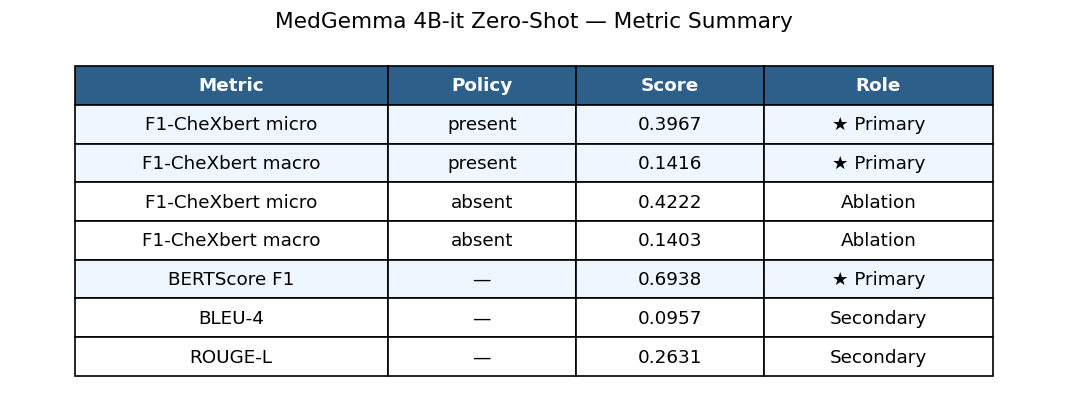

In [17]:
# ── Figure 5: Metric summary as a clean table figure ──────────────────────────
metric_rows = [
    ['F1-CheXbert micro',  'present',   f"{f1_present['f1_chexbert_micro_present']:.4f}", '★ Primary'],
    ['F1-CheXbert macro',  'present',   f"{f1_present['f1_chexbert_macro_present']:.4f}", '★ Primary'],
    ['F1-CheXbert micro',  'absent',    f"{f1_absent['f1_chexbert_micro_absent']:.4f}",   'Ablation'],
    ['F1-CheXbert macro',  'absent',    f"{f1_absent['f1_chexbert_macro_absent']:.4f}",   'Ablation'],
    ['BERTScore F1',       '—',         f'{bertscore_f1:.4f}',                              '★ Primary'],
    ['BLEU-4',             '—',         f'{bleu4:.4f}',                                     'Secondary'],
    ['ROUGE-L',            '—',         f'{rouge_l:.4f}',                                   'Secondary'],
]
col_labels = ['Metric', 'Policy', 'Score', 'Role']

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.axis('off')
tbl = ax.table(
    cellText=metric_rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=[0.30, 0.18, 0.18, 0.22],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.0, 1.8)

# Style header
for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#2c5f8a')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# Highlight primary metrics
for i, row in enumerate(metric_rows, start=1):
    if '★' in row[3]:
        for j in range(len(col_labels)):
            tbl[(i, j)].set_facecolor('#eef6ff')

ax.set_title('MedGemma 4B-it Zero-Shot — Metric Summary', fontsize=13, pad=12)
plt.tight_layout()
fig_path = FIGURES_DIR / 'baseline_metric_summary.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved {fig_path}')
plt.show()

## STEP 10 — Save results to disk

In [18]:
results_payload = {
    'model': MODEL_ID,
    'split': 'test',
    'n_studies': len(test_df),
    'protocol': 'zero_shot_greedy',
    'metrics': {
        'f1_chexbert_micro_present': f1_present['f1_chexbert_micro_present'],
        'f1_chexbert_macro_present': f1_present['f1_chexbert_macro_present'],
        'f1_chexbert_micro_absent' : f1_absent['f1_chexbert_micro_absent'],
        'f1_chexbert_macro_absent' : f1_absent['f1_chexbert_macro_absent'],
        'bertscore_f1'             : bertscore_f1,
        'bleu4'                    : bleu4,
        'rouge_l'                  : rouge_l,
        'per_label_f1_present'     : f1_present['per_label_f1_present'],
        'per_label_f1_absent'      : f1_absent['per_label_f1_absent'],
    },
    'bertscore_per_study': bertscore_per_study.tolist(),
    'bleu4_per_study'    : bleu_per_study.tolist(),
}

out_json = RESULTS_DIR / 'baseline_results.json'
out_json.parent.mkdir(parents=True, exist_ok=True)
out_json.write_text(json.dumps(results_payload, indent=2))
print(f'Saved results → {out_json}')

print('\nAll figures saved to reports/figures/:')
for f in sorted(FIGURES_DIR.glob('baseline_*.png')):
    print(f'  {f.name}')

Saved results → ../reports/baseline_results.json

All figures saved to reports/figures/:
  baseline_metric_summary.png
  baseline_per_label_f1.png
  baseline_policy_ablation.png
  baseline_qualitative_examples.png
  baseline_score_distributions.png


In [19]:
# ── STEP 11 — Export eval_metrics_zero_shot.json in standard format ───────────
#
# baseline_results.json uses different key names than eval_metrics_*.json files:
#   f1_chexbert_micro_present  →  chexbert_micro_f1
#   f1_chexbert_macro_present  →  chexbert_macro_f1
#   per_label_f1_present       →  per_label_f1
#
# This cell reshapes the already-computed metrics into the canonical format so
# NB04's grand comparison can load the zero-shot row uniformly alongside
# fine-tuned variants — no model inference is run here.

eval_metrics_zero_shot = {
    'variant':             'zero_shot',
    'bertscore_f1':        results_payload['metrics']['bertscore_f1'],
    'chexbert_micro_f1':   results_payload['metrics']['f1_chexbert_micro_present'],
    'chexbert_macro_f1':   results_payload['metrics']['f1_chexbert_macro_present'],
    'bleu4':               results_payload['metrics']['bleu4'],
    'rouge_l':             results_payload['metrics']['rouge_l'],
    'per_label_f1':        results_payload['metrics']['per_label_f1_present'],
    'bertscore_per_study': results_payload['bertscore_per_study'],
}

out_zs = RESULTS_DIR / 'eval_metrics_zero_shot.json'
out_zs.write_text(json.dumps(eval_metrics_zero_shot, indent=2))
print(f'Saved → {out_zs}')

print(f"\nZero-shot metrics (standard format):")
print(f"  BERTScore-F1       : {eval_metrics_zero_shot['bertscore_f1']:.4f}")
print(f"  CheXbert micro-F1  : {eval_metrics_zero_shot['chexbert_micro_f1']:.4f}")
print(f"  CheXbert macro-F1  : {eval_metrics_zero_shot['chexbert_macro_f1']:.4f}")
print(f"  BLEU-4             : {eval_metrics_zero_shot['bleu4']:.4f}")
print(f"  ROUGE-L            : {eval_metrics_zero_shot['rouge_l']:.4f}")

Saved → ../reports/eval_metrics_zero_shot.json

Zero-shot metrics (standard format):
  BERTScore-F1       : 0.6938
  CheXbert micro-F1  : 0.3967
  CheXbert macro-F1  : 0.1416
  BLEU-4             : 0.0957
  ROUGE-L            : 0.2631


## Summary — fill in after running

| Metric | Value |
|--------|-------|
| Test studies | ??? |
| F1-CheXbert micro (present) | ??? |
| F1-CheXbert macro (present) | ??? |
| BERTScore F1 | ??? |
| BLEU-4 | ??? |
| ROUGE-L | ??? |
| Weakest label (F1) | ??? |
| Strongest label (F1) | ??? |

**Next step:** `notebooks/03_train_kaggle.ipynb` — fine-tune with QLoRA + IS sampler,
then compare back to these numbers in `04_eval_and_figures.ipynb`.

**Domain shift experiment:** `src/eval/shift_experiment.py` — importance-weighted
re-evaluation sweeping target prevalence of each label.